### 1.1 Carga de Librerías

In [1]:
import pandas as pd # Librerías para el análisis y manipulación de datos 
import numpy as np
import matplotlib.pyplot as plt # Librerías para creación de gráficos, matrices de correlación y confusión
import seaborn as sns
from sklearn.model_selection import train_test_split# Librerías de preprocesamiento de datos
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix # Librerías de evaluación de modelos y métricas
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import cross_validate, cross_val_predict # Librería validación cruzada (varias metricas)
from sklearn.linear_model import LogisticRegression # Librerías para algoritmos de regresión logística
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV # Librerías para la optimización de hiperparámetros
from scipy.stats import uniform, randint
import joblib # Librerías para guardar modelos
import os

# Librerías para los modelos de clasificación
from sklearn.linear_model import LogisticRegression 
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Configuracion para que pandas muestre el dataframe completos y correctamente
pd.set_option('display.max_rows', None)  # Mostrar todas las filas
pd.set_option('display.max_columns', None)  # Mostrar todas las columnas
pd.set_option('display.expand_frame_repr', False)  # Evitar cortar en varias líneas
pd.set_option('display.max_colwidth', None)  # Evitar cortar el contenido de las celdas

### 1.2 Carga y Visualización Inicial del Dataset

In [ ]:
df = pd.read_csv('../dataset/Medicaldataset.csv')
print("Número de filas y columnas:", df.shape)
print(df.head())
print(df.describe())
print(df.info())

Número de filas y columnas: (1319, 9)
   Age  Gender  Heart rate  Systolic blood pressure  Diastolic blood pressure  Blood sugar  CK-MB  Troponin    Result
0   64       1          66                      160                        83        160.0   1.80     0.012  negative
1   21       1          94                       98                        46        296.0   6.75     1.060  positive
2   55       1          64                      160                        77        270.0   1.99     0.003  negative
3   64       1          70                      120                        55        270.0  13.87     0.122  positive
4   55       1          64                      112                        65        300.0   1.08     0.003  negative
               Age       Gender   Heart rate  Systolic blood pressure  Diastolic blood pressure  Blood sugar        CK-MB     Troponin
count  1319.000000  1319.000000  1319.000000              1319.000000               1319.000000  1319.000000  1319.0000

Estadísticas descriptivas de las columnas numéricas del DataFrame.

Información general del datagrame, numero total de entradas, tipo de datos y valores no nulos

### 1.3 Limpieza y Conversión de Datos

A continuación se converitran los valores de la columna 'Result' a binarios: 1 para 'positive', 0 para 'negative' y None en otros casos

In [3]:
df['Result'] = df['Result'].apply(lambda x: 1 if x == 'positive' else 0 if x == 'negative' else None)

Como se puede ver, los valores 'positive' y 'negative' fueron convertidos correctamente a 1 y 0, respectivamente

In [4]:
print(df.head())

   Age  Gender  Heart rate  Systolic blood pressure  Diastolic blood pressure  Blood sugar  CK-MB  Troponin  Result
0   64       1          66                      160                        83        160.0   1.80     0.012       0
1   21       1          94                       98                        46        296.0   6.75     1.060       1
2   55       1          64                      160                        77        270.0   1.99     0.003       0
3   64       1          70                      120                        55        270.0  13.87     0.122       1
4   55       1          64                      112                        65        300.0   1.08     0.003       0


### 1.4 Exploración de Valores Nulos

Valores nulos por columna en el DataFrame.

In [5]:
print(df.isnull().sum())

Age                         0
Gender                      0
Heart rate                  0
Systolic blood pressure     0
Diastolic blood pressure    0
Blood sugar                 0
CK-MB                       0
Troponin                    0
Result                      0
dtype: int64


###  1.5 Visualización de Correlación

Visualiza la correlación entre variables numéricas con un mapa de calor.

En particular aquellas en relación con la variable objetivo (Result)

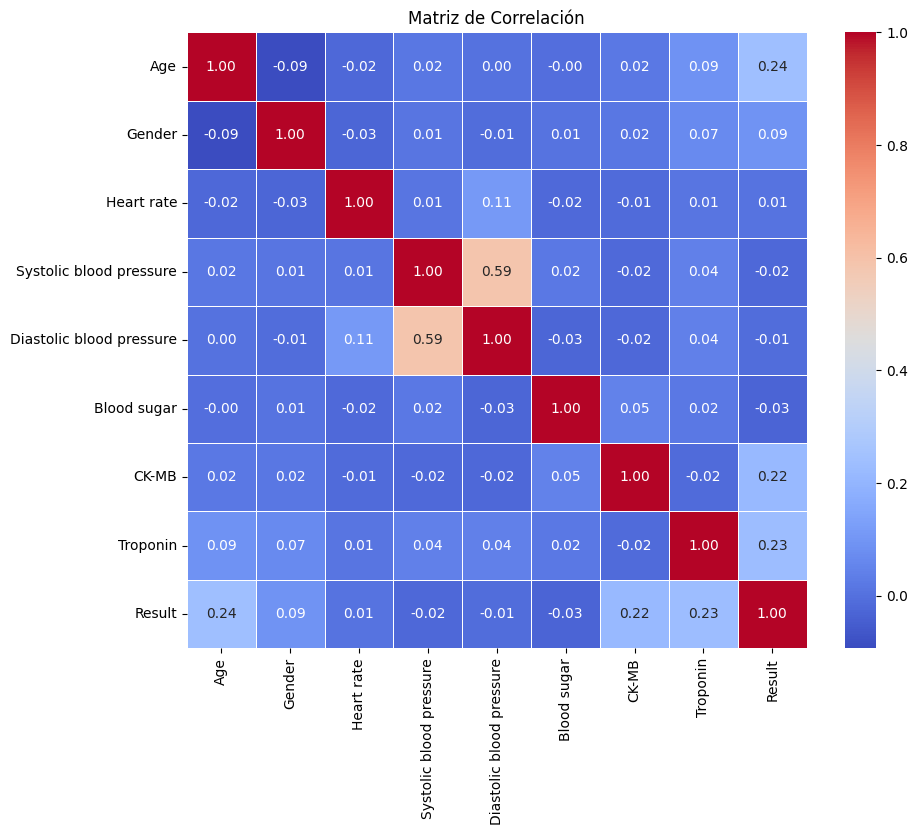

In [6]:
matriz_correlacion = df.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(10,8))
sns.heatmap(matriz_correlacion, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Matriz de Correlación")
plt.show()

###  1.6 Selección Previa de Variables a Transformar

Se seleccionan las variables `Age`, `CK-MB` y `Troponin` por ser las que presentan mayor correlación con la variable objetivo `Result`. 

`Gender` tiene una correlación baja con la variable objetivo, por lo tanto no se tomará en cuenta en esta etapa. Sin embargo, se planea realizar pruebas posteriores para evaluar si su adición mejora el rendimiento del modelo.


###  1.7 Transformación de Variables (log y log1p)

Aplicación de transformaciones logarítmicas (log y log1p) a las columnas 'Age', 'CK-MB' y 'Troponin' para reducir la asimetría en los datos.

Esto mejora su distribucion y disminuye la inlfuencia de valores extremos o sesgos.

In [7]:
columnas_elegidas = ['Age','CK-MB','Troponin']
for col in columnas_elegidas:
    df[col+'_log'] = np.log(df[col] + 1e-10 )
for col in columnas_elegidas:
    df[col+'_log1'] = np.log1p(df[col])

Movemos la columna Result al final del dataframe

In [8]:
df['Result'] = df.pop('Result')

# actualizar columnas elegidas incluye log y log1p
columnas_elegidas = ['Age','CK-MB','Troponin','Gender','Age_log','CK-MB_log','Troponin_log','Age_log1','CK-MB_log1','Troponin_log1']

### 1.8 Distribución de Variables

Visualisamos la distribucion de los datos mediante graficas para observar la distribución de los datos, nos sirve para identificar patrones, sesgos, valores atipicos.

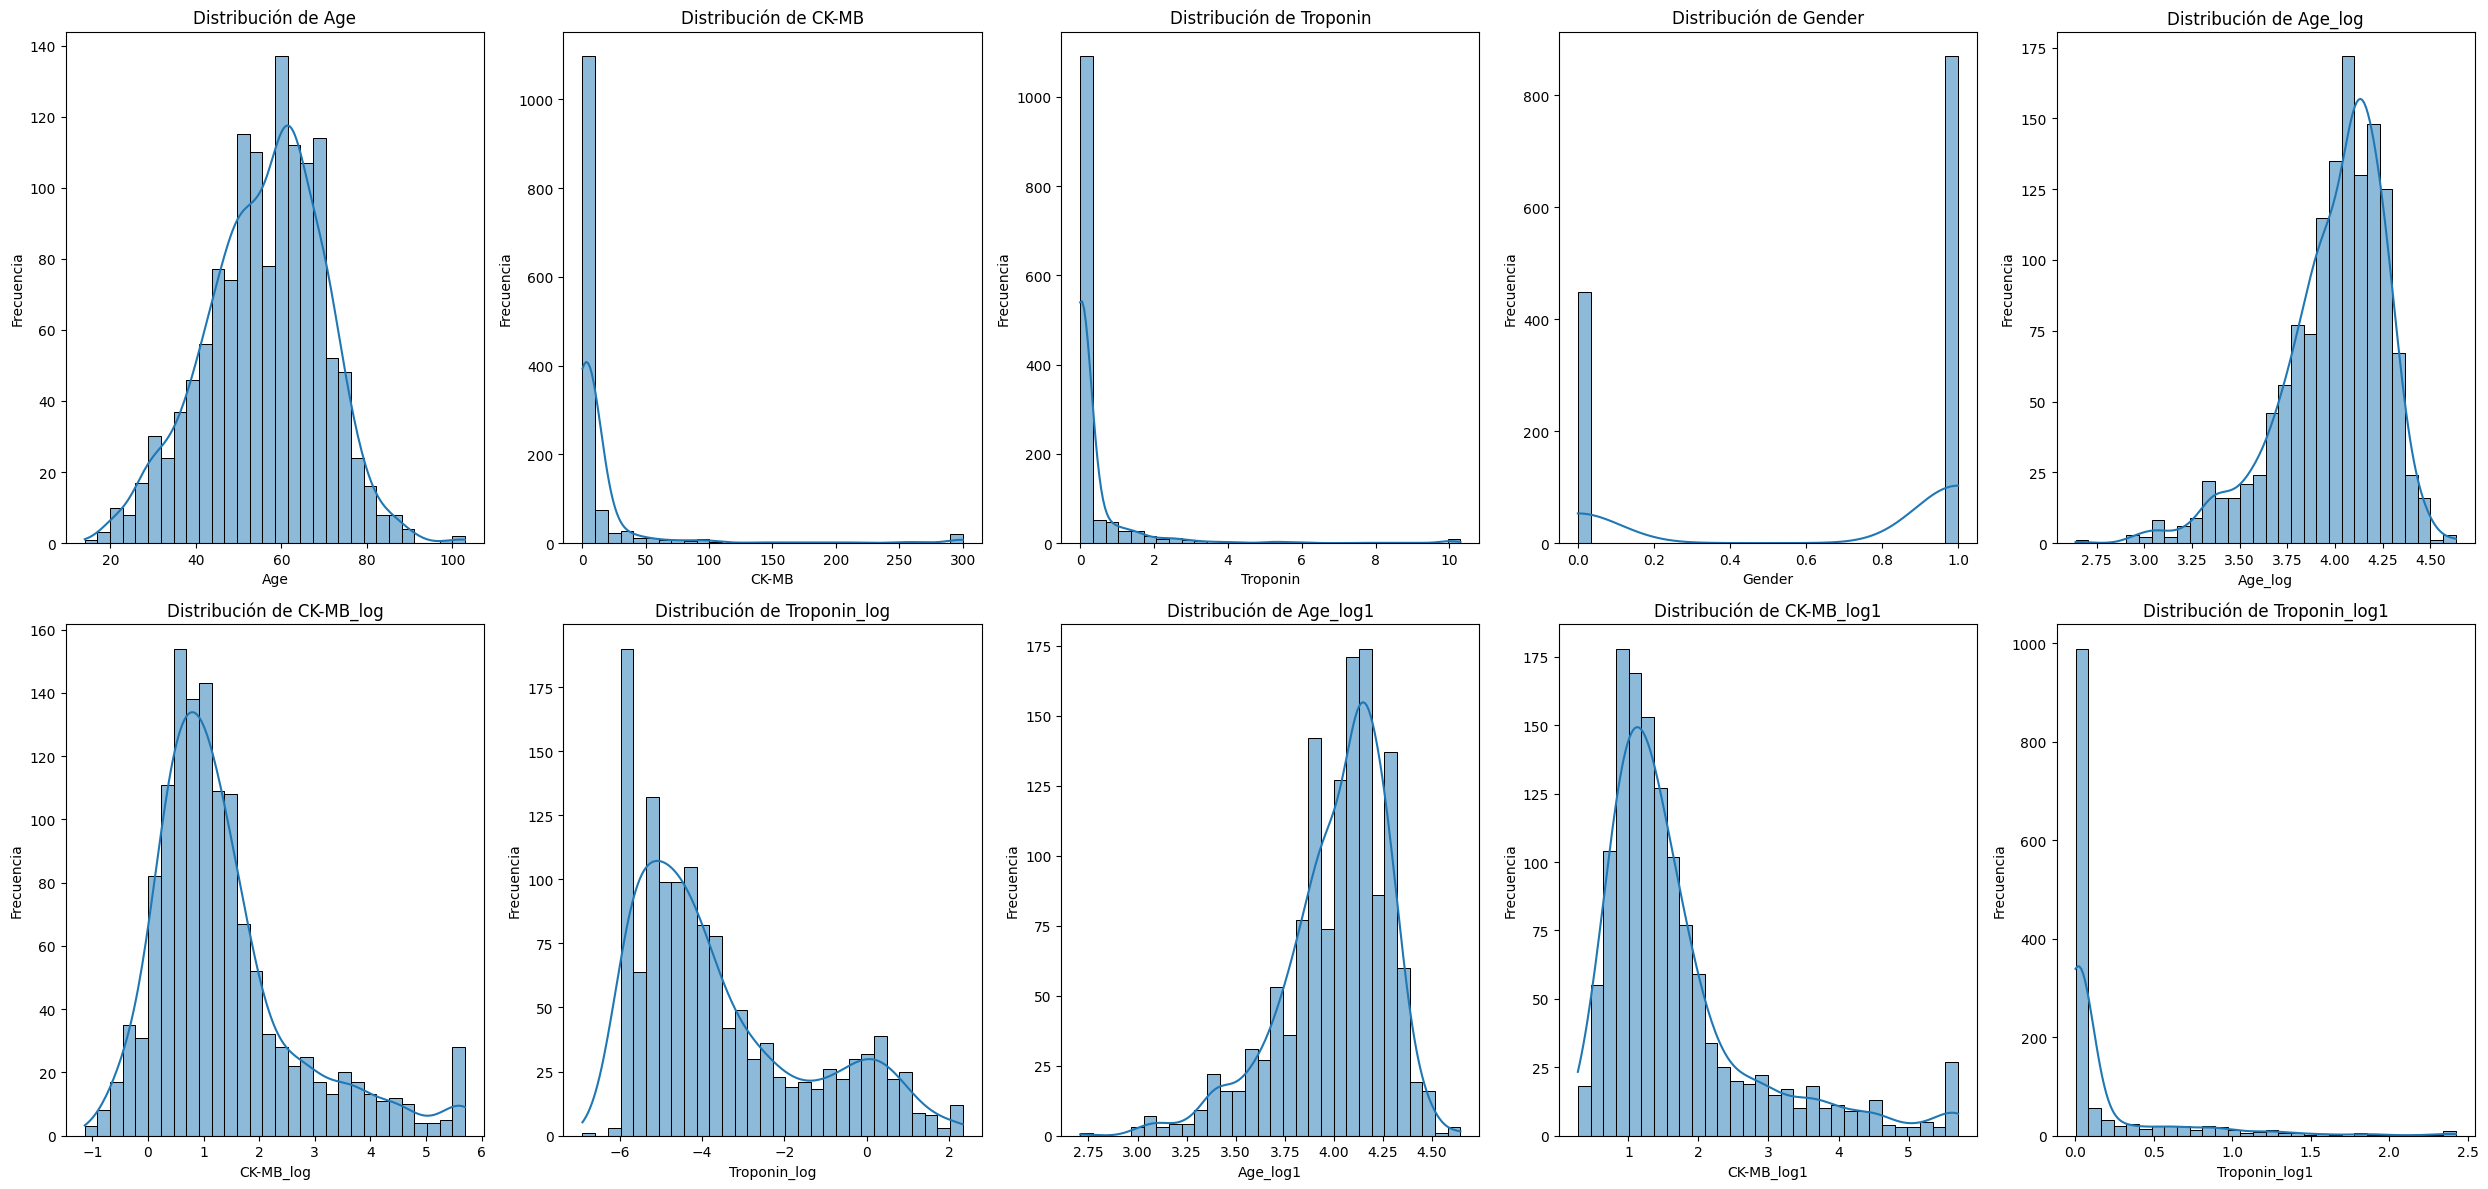

In [9]:
numero_columnas = 5 # Número de columnas para las subgráficas
# Calcular el número de filas necesarias
numero_filas = (len(columnas_elegidas) + numero_columnas - 1) // numero_columnas  

# Crear la figura con subgráficas
fig, axes = plt.subplots(nrows=numero_filas, ncols=numero_columnas, figsize=(25, numero_filas * 6))
axes = axes.flatten()

# Graficar la distribución de cada variable en una subgráfica
for i, col in enumerate(columnas_elegidas):
    sns.histplot(df[col], kde=True, bins=30, ax=axes[i])
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frecuencia")

plt.tight_layout() # Ajustar el layout para que no se solapen
plt.show() # Mostrar el gráfico

### 1.9 Elección de variables predictoras

Aqui podemos observar la correlacion de las varables con respecto a la variable objetivo en este caso **Result**, y podemos elegir cuales variables originales o transformadas utilizar.

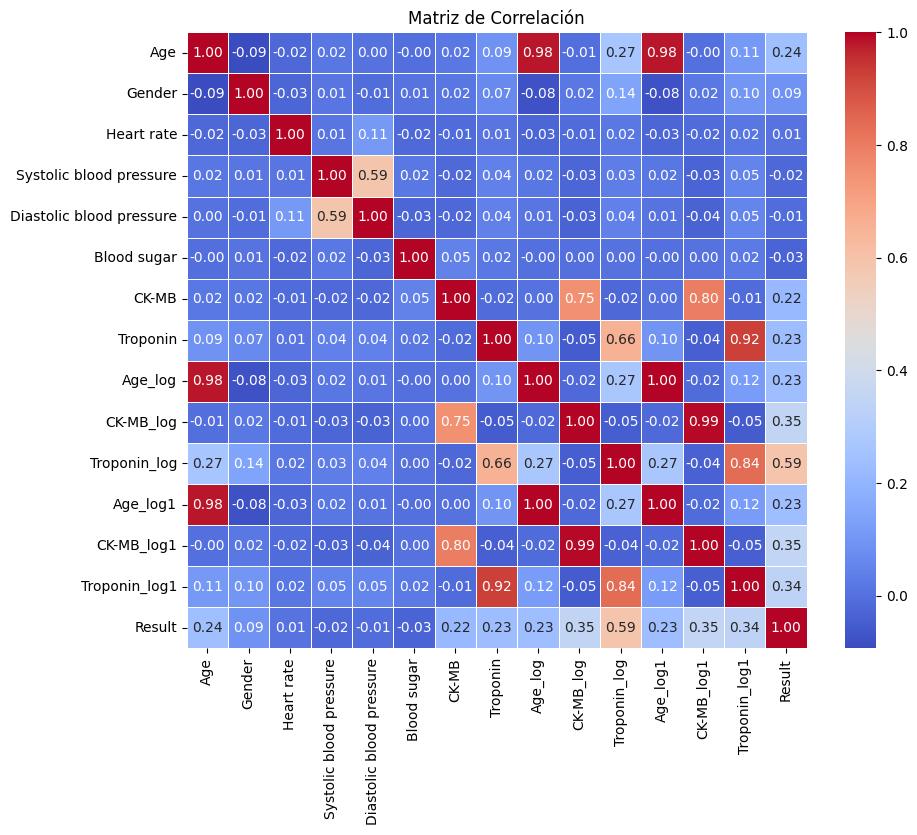

In [10]:
matriz_correlacion = df.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(10,8))
sns.heatmap(matriz_correlacion, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Matriz de Correlación")
plt.show()

Como resultado de esta comparacion se hizo la siguiente eleccion dinal de las variables:
- Age:          En su forma original
- Gender:       En su forma original 
- CK-MB_log:    Transformada mediante logaritmo 
- Troponin_log: Transformada mediante logaritmo 
- Result:       Variable Objetivo
- **Nota: no se tiene planeado utilizar la variable 'Gender', sera para futuras pruebas.**

### Actualizamos nuestro Dataframe

In [11]:
# exportar el dataset a csv con las columnas Age, CK-MB_log y Troponin_log y Result
df= df[['Age', 'Gender','CK-MB', 'Troponin','CK-MB_log', 'Troponin_log', 'Result']]

### 1.10 Análisis Visual por Clase (Boxplots y Rangos)

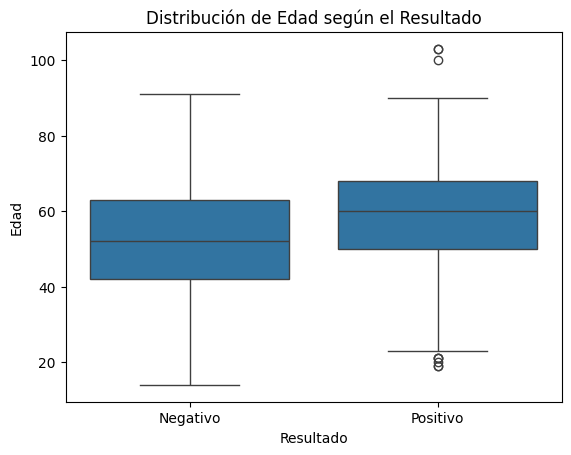

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='Result', y='Age', data=df)
plt.xticks([0, 1], ['Negativo', 'Positivo'])
plt.title("Distribución de Edad según el Resultado")
plt.xlabel("Resultado")
plt.ylabel("Edad")
plt.show()


C:\Users\eliut\AppData\Local\Temp\ipykernel_22628\1505106987.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  proporcion = df.groupby(labels)['Result'].mean().reset_index()


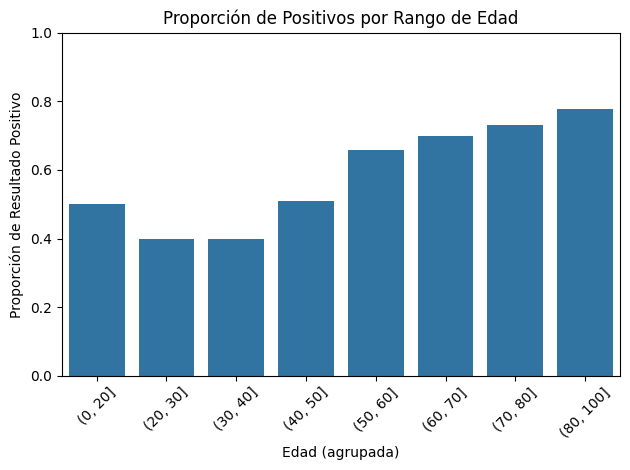

In [13]:


# Crear rangos de edad sobre la marcha sin agregar columna
bins = [0, 20, 30, 40, 50, 60, 70, 80, 100]
labels = pd.cut(df['Age'], bins=bins)

# Calcular proporción de positivos por grupo
proporcion = df.groupby(labels)['Result'].mean().reset_index()
proporcion.columns = ['Edad_rango', 'Proporcion_Positivos']

# Graficar
sns.barplot(x='Edad_rango', y='Proporcion_Positivos', data=proporcion)
plt.xticks(rotation=45)
plt.title("Proporción de Positivos por Rango de Edad")
plt.ylabel("Proporción de Resultado Positivo")
plt.xlabel("Edad (agrupada)")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

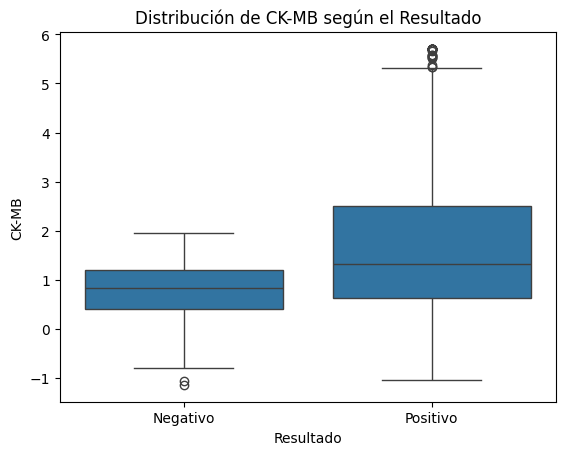

In [14]:
sns.boxplot(x='Result', y='CK-MB_log', data=df)
plt.xticks([0, 1], ['Negativo', 'Positivo'])
plt.title("Distribución de CK-MB según el Resultado")
plt.xlabel("Resultado")
plt.ylabel("CK-MB")
plt.show()

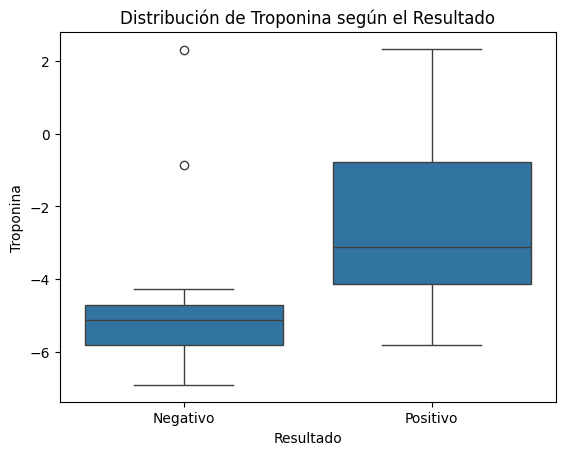

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='Result', y='Troponin_log', data=df)
plt.xticks([0, 1], ['Negativo', 'Positivo'])
plt.title("Distribución de Troponina según el Resultado")
plt.xlabel("Resultado")
plt.ylabel("Troponina")
plt.show()


### 1.11 Outliers (Boxplot Interactivo)

In [16]:
import plotly.express as px

# Crear gráfico de bigotes interactivo combinando Positivo y Negativo
variable = 'CK-MB_log'
fig = px.box(df, y=variable, 
             points="all",  # Incluye todos los puntos individuales
             title=f"Distribución combinada de {variable}",
             labels={variable: variable})

# Mostrar el gráfico interactivo
fig.show()

# Repetir el proceso para Troponin_log
variable = 'Troponin_log'
fig = px.box(df, y=variable, 
             points="all",
             title=f"Distribución combinada de {variable}",
             labels={variable: variable})

fig.show()


### 1.12 Tratamiento de Outliers (Filtrado por umbral)

In [17]:
# Filtrar valores atípicos para CK-MB_log y Troponin_log utilizando diferentes métodos

# Filtrar valores por umbrales definidos y reemplazar por la media

ckmb_media = df['CK-MB_log'].mean()
troponin_media = df['Troponin_log'].mean()
df['CK-MB_filtrado'] = df['CK-MB_log'].apply(lambda x: x if x <= 3.62 else ckmb_media)
df['Troponin_filtrado'] = df['Troponin_log'].apply(lambda x: x if x <= 1.46 else troponin_media)

# pop a result
df['Result'] = df.pop('Result')

 ### 1.13 Nueva Matriz de Correlación (Post-Filtrado)

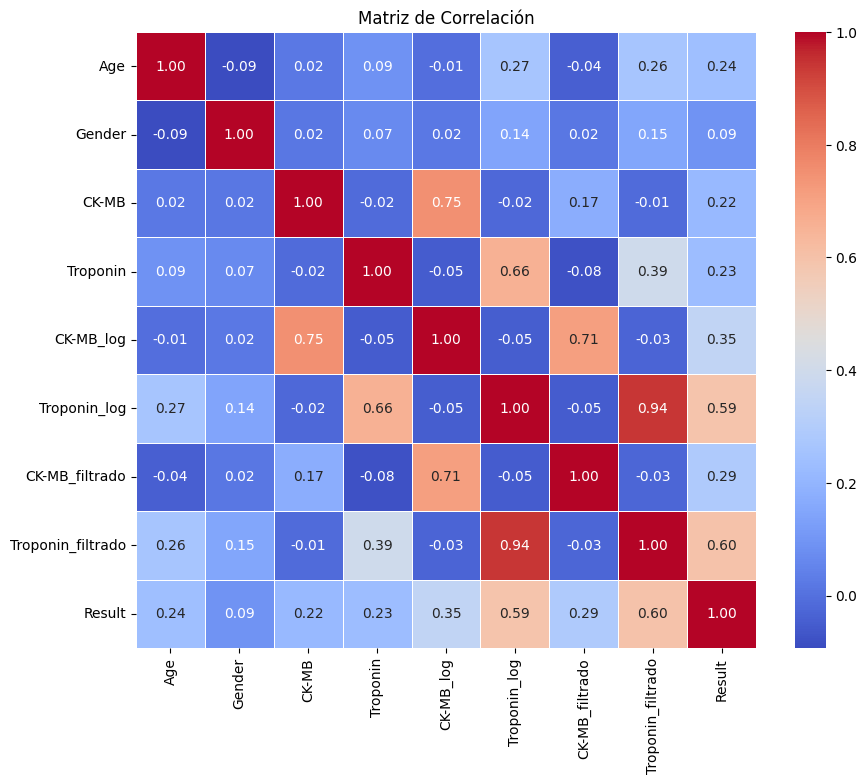

In [18]:
matriz_correlacion = df.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(10,8))
sns.heatmap(matriz_correlacion, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Matriz de Correlación")
plt.show()

### 1.14 Exportación del Dataset Preprocesado

In [ ]:
df.to_csv('dataset_final.csv', index=False)

In [20]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                1319 non-null   int64  
 1   Gender             1319 non-null   int64  
 2   CK-MB              1319 non-null   float64
 3   Troponin           1319 non-null   float64
 4   CK-MB_log          1319 non-null   float64
 5   Troponin_log       1319 non-null   float64
 6   CK-MB_filtrado     1319 non-null   float64
 7   Troponin_filtrado  1319 non-null   float64
 8   Result             1319 non-null   int64  
dtypes: float64(6), int64(3)
memory usage: 92.9 KB
None
